# Snow synthesis prototype: NetCDF ERA5 + JRA-3Q

Prototypes the snow synthesis method for the 2024-01-02-forward era (NetCDF ERA5 from the AWS mirror + JRA-3Q, replacing GRIB ERA5 + JRA-55). Same algorithm as the production `preprocess_snow.py`: ERA5 snow depth (`SD`) is the primary field; JRA snow water equivalent (interpolated onto the ERA5 grid) replaces it only inside the glacier mask and wherever ERA5's own value looks implausible (`>= THRESH`).

Run against January 2024 -- the first month with both a NetCDF ERA5 `sd` file (backfilled specifically for this) and a JRA-3Q file available. Produces one `synth_*.nc` output file alongside (not overwriting) the raw ERA5 input, for inspection before this logic is wired into the production pipeline.

See `../dsworkflow/processing_code/preprocess_snow_jra3q.py` for the script version of this same method.

In [ ]:
import calendar as cal
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

YRMONTH = "202401"
THRESH = 1.0  # m of water equivalent; same as production preprocess_snow.py

BASEDIR = Path("/beegfs/DYNDOWN/cwaigl/ERA5_WRF")
ERADIR = BASEDIR / "era5_nc" / "e5.oper.an.sfc" / YRMONTH
JRADIR = BASEDIR / "jra3q_nc"
MASKPATH = BASEDIR / "scripts" / "masks" / "glaciermask_thresh_1.0m_dilate1.nc"

ERA_SD_PREFIX = "e5.oper.an.sfc.128_141_sd.ll025sc."
JRA_PREFIX = "jra3q.anl_surf.0_1_13.weasd-sfc-an-gauss."
JRA_VAR = "weasd-sfc-an-gauss"

# output written alongside the raw ERA5 input, "synth_"-prefixed --
# same convention as production preprocess_snow.py, never overwrites the raw sd file

## 1. ERA5 snow depth (primary field)

Already in "m of water equivalent" -- no unit conversion needed. This is the file backfilled earlier this session specifically because `aws_era5_month.py` had been dropping `128_141_sd` by mistake.

In [ ]:
era_fpaths = sorted(ERADIR.glob(f"{ERA_SD_PREFIX}*.nc"))
assert len(era_fpaths) == 1, era_fpaths
era_fpath = era_fpaths[0]
print(era_fpath)

ds_era = xr.open_dataset(era_fpath, engine="netcdf4")
sd_raw = ds_era.SD
sd_raw

/beegfs/DYNDOWN/cwaigl/ERA5_WRF/era5_nc/e5.oper.an.sfc/202401/e5.oper.an.sfc.128_141_sd.ll025sc.2024010100_2024013123.nc


<xarray.DataArray 'SD' (time: 744, latitude: 721, longitude: 1440)> Size: 3GB
[772450560 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/14)
    long_name:                                  Snow depth
    short_name:                                 sd
    units:                                      m of water equivalent
    original_format:                            WMO GRIB 1 with ECMWF local t...
    ecmwf_local_table:                          128
    ecmwf_parameter:                            141
    ...                                         ...
    grid_specification:                         0.25 degree x 0.25 degree fro...
    rda_dataset:                                ds633.0
    rda_dataset_url:                            https:/rda.ucar.edu/datasets/...
    rda_dataset_doi:                            DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                          ERA5 atmospheric surface anal...
    QuantizeBitGroomNumberOfSignificantDigits:  7

## 2. JRA-3Q snow water equivalent (gap-filler)

Units are `kg m-2` (i.e. mm w.e.), needs `/1000` to match ERA5's meters. Dims are `lat`/`lon`, **not** `latitude`/`longitude` like ERA5 -- renamed here, otherwise `interp_like` silently fails to align the two grids and broadcasts instead of interpolating (a real gotcha found while building this: JRA-55's cfgrib-loaded dims happened to already be named `latitude`/`longitude`, so this issue didn't exist in the old pipeline).

In [ ]:
def jra3q_calendarstr(yrmonth: str) -> str:
    """JRA-3Q files are always monthly: YYYYMM0100_YYYYMM<lastday>18."""
    year, month = int(yrmonth[:4]), int(yrmonth[4:6])
    lastday = cal.monthrange(year, month)[1]
    return f"{yrmonth}0100_{yrmonth}{lastday:02d}18"

jra_fpath = JRADIR / f"{JRA_PREFIX}{jra3q_calendarstr(YRMONTH)}.nc"
print(jra_fpath, jra_fpath.exists())

ds_jra = xr.open_dataset(jra_fpath, engine="netcdf4")
snow_jra_raw = ds_jra[JRA_VAR]
print(snow_jra_raw.dims, snow_jra_raw.attrs["units"])

snow_jra = snow_jra_raw.rename({"lat": "latitude", "lon": "longitude"})
snow_jra

/beegfs/DYNDOWN/cwaigl/ERA5_WRF/jra3q_nc/jra3q.anl_surf.0_1_13.weasd-sfc-an-gauss.2024010100_2024013118.nc True
('time', 'lat', 'lon') kg m-2


<xarray.DataArray 'weasd-sfc-an-gauss' (time: 124, latitude: 480, longitude: 960)> Size: 229MB
[57139200 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 992B 2024-01-01 ... 2024-01-31T18:00:00
  * latitude   (latitude) float64 4kB 89.71 89.34 88.97 ... -88.97 -89.34 -89.71
  * longitude  (longitude) float64 8kB 0.0 0.375 0.75 ... 358.9 359.2 359.6
Attributes: (12/75)
    group:                                               anl_surf
    jma_group_description:                               Surface analysis fie...
    rda_group_description:                               JRA-3Q surface analy...
    rda_group_number:                                    7
    short_name:                                          weasd-sfc-an-gauss
    jma_short_name:                                      weasd
    ...                                                  ...
    gas_constant_for_dry_air:                            287.04 J K-1 kg-1
    specific_heat_of_dry_air_at_constant_pressure:       1004.6 J K-1 kg-1
    latent_heat_of_vaporization:                         2.507e+6 J kg-1
    solar_constant:                                      1365 W m-2
    jma_saturated_vapor_pressure:                        The saturated vapor ...
    jma_local_issues_with_sea_ice_parameters:            JRA-3Q contains erro...

## 3. Glacier mask + masking/threshold

Same mask file and threshold as production: mask out glaciers (`glaciermask == 0` keeps non-glacier ERA5 values), then also mask out any ERA5 value `>= THRESH` as implausible. Both masked-out regions get filled from JRA below.

In [ ]:
with xr.open_dataset(MASKPATH) as src:
    glaciermask = src.glaciermask.load()

sd = sd_raw.where(glaciermask == 0)
sd = sd.where(sd < THRESH)

frac_masked = float((sd.isnull() & sd_raw.notnull()).sum()) / sd_raw.size
print(f"fraction of ERA5 grid masked out (glacier or implausible): {frac_masked:.4f}")

fraction of ERA5 grid masked out (glacier or implausible): 0.1229


## 4. Interpolate JRA-3Q onto the ERA5 grid and fill

`interp_like` interpolates over every dim shared by name between the two arrays -- since both now share `latitude`/`longitude` **and** `time`, this does spatial regridding (JRA-3Q's coarser Gaussian grid -> ERA5's 0.25 deg grid) and temporal upsampling (JRA-3Q's 6-hourly -> ERA5's hourly) in one call. Same trick the original GRIB/JRA-55 code relied on.

In [ ]:
snow_jra_regridded = snow_jra.fillna(0).interp_like(ds_era, method="linear") / 1000
combined = sd.combine_first(snow_jra_regridded)

n_nan = int(combined.isel(time=0).isnull().sum())
print("NaN cells left in combined at t=0 (before edge fill):", n_nan)
print("combined min/mean/max (m w.e.):", float(combined.min()), float(combined.mean()), float(combined.max()))

NaN cells left in combined at t=0 (before edge fill): 2960


combined min/mean/max (m w.e.): 0.0 0.018680973947341376 1.7358307287941852


### Known edge case: `interp_like` doesn't extrapolate

JRA-3Q's Gaussian grid tops out at lat +-89.71324 deg and lon 359.625 deg E -- just short of ERA5's +-90 deg / 359.75 deg E. `interp_like` returns NaN (no extrapolation by default) for ERA5 grid points outside JRA-3Q's coverage: the 2 southernmost latitude rows, plus a single longitude column adjacent to the date line. Those only surface as leftover NaN in `combined` where ERA5's own `sd` was *also* masked out at that exact cell (glacier or implausible-value mask) -- found entirely in the Antarctic band (~-70 deg and south) for this test month, well outside any Alaska/Arctic WRF domain.

Patched with a final `fillna(0)` -- physically reasonable for a redundant edge sliver (no snow assumed where neither source has valid data) and keeps the output file free of NaN holes.

In [ ]:
combined = combined.fillna(0)
print("any NaN left after edge fill?", bool(combined.isnull().any()))

any NaN left after edge fill? False


## 5. Sanity-check plot

Mid-month timestep: raw ERA5, the filled-in region (glacier + implausible mask), and the final combined field.

Text(0.5, 0.98, '2024-01-16T12:00:00.000000000')

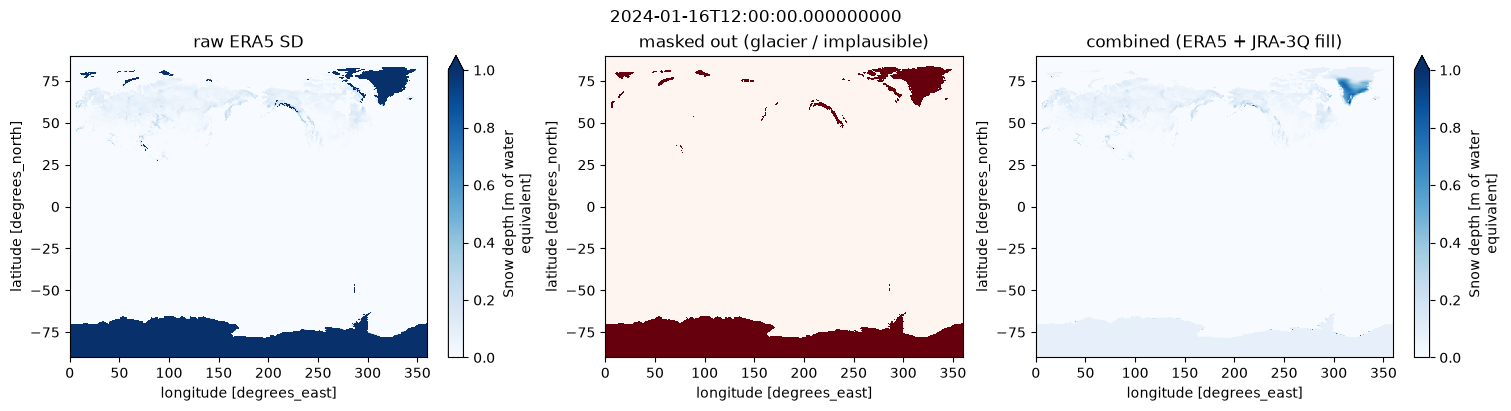

In [ ]:
tstep = sd_raw.sizes["time"] // 2
filled_mask = sd.isel(time=tstep).isnull() & sd_raw.isel(time=tstep).notnull()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
sd_raw.isel(time=tstep).plot(ax=axes[0], vmin=0, vmax=THRESH, cmap="Blues")
axes[0].set_title("raw ERA5 SD")
filled_mask.plot(ax=axes[1], cmap="Reds", add_colorbar=False)
axes[1].set_title("masked out (glacier / implausible)")
combined.isel(time=tstep).plot(ax=axes[2], vmin=0, vmax=THRESH, cmap="Blues")
axes[2].set_title("combined (ERA5 + JRA-3Q fill)")
fig.suptitle(str(sd_raw.isel(time=tstep).time.values))

## 6. Write the replacement snow file

Written alongside the raw ERA5 `sd` file with a `synth_` prefix -- same naming convention as production `preprocess_snow.py`. The raw input is untouched.

In [ ]:
out_fpath = ERADIR / ("synth_" + era_fpath.name)

ds_out = ds_era.copy()
ds_out["sd"] = combined  # lowercase "sd", added alongside "SD" -- matches preprocess_snow.py's convention
ds_out.to_netcdf(out_fpath, engine="netcdf4")

ds_era.close()
ds_jra.close()

print("wrote", out_fpath)

wrote /beegfs/DYNDOWN/cwaigl/ERA5_WRF/era5_nc/e5.oper.an.sfc/202401/synth_e5.oper.an.sfc.128_141_sd.ll025sc.2024010100_2024013123.nc
